In [1]:
# ============================================================
# Cell 0 — Parameters
# ============================================================
"""
Parameters from Table I of:
Gioannini & Rossetti, "Time-Domain Traveling Wave Model of Quantum Dot DFB Lasers"
IEEE J. Sel. Top. Quantum Electron., Vol. 17, No. 5, 2011

All values are in SI units unless noted.
"""

import numpy as np
import os

# ── Physical constants ────────────────────────────────────────────────────────
q        = 1.602176634e-19   # elementary charge (C)
hbar     = 1.054571817e-34   # reduced Planck constant (J·s)
kB       = 1.380649e-23      # Boltzmann constant (J/K)
c0       = 2.997924580e8     # speed of light in vacuum (m/s)
eps0     = 8.854187817e-12   # vacuum permittivity (F/m)
m0       = 9.1093837015e-31  # free electron mass (kg)
T        = 300.0             # room temperature (K)

# ── Material parameters ───────────────────────────────────────────────────────
h_w      = 5e-9              # QD layer height (m)
eta      = 3.3445            # effective refractive index (dimensionless)
N_l      = 8                 # number of QD layers
N_D      = 5.9e14            # QD surface density (m⁻²)  [5.9×10¹⁰ cm⁻² → ×10⁴]
N_groups = 51                # number of QD groups for inhomogeneous broadening

# State degeneracies: D_m for m = ES2, ES1, GS
D = {
    'ES2': 6,
    'ES1': 4,
    'GS':  2,
}

hbar_Gamma = 7e-3 * q       # homogeneous linewidth (J)  [7 meV → ×q]
Gamma      = hbar_Gamma / hbar  # dephasing rate (rad/s)

Delta_E    = 38e-3 * q      # FWHM of inhomogeneous broadening (J)  [38 meV]

# Dipole matrix elements A_m  (cm³·eV → m³·J)
# 1 cm³·eV = 1e-6 m³ × 1.602e-19 J  →  multiply by 1e-6 * q
A = {
    'ES1': 1.26e-20 * 1e-6 * q,   # m³·J
    'GS':  2.03e-20 * 1e-6 * q,   # m³·J
}

# SCH diffusion/transport times (s)
tau_c_e_W  = 1.2e-12        # electron transport time across SCH (s)
tau_c_h_W  = 23.2e-12       # hole transport time across SCH (s)

tau_e_e_W  = 0.0492e-12

# Electron relaxation times τ_c^{e,m} for m = ES2, ES1, GS (s)
tau_c_e = {
    'ES2': 3e-12,
    'ES1': 2e-12,
    'GS':  2e-12,
}

tau_e_e_im = {
    'ES2': 6.15e-12,
    'ES1': 7.99e-12,
    'GS':  10.63e-12,
}

# Interband recombination time in the WL (s)
tau_r_e_W  = 100e-12

tau_e_h_qd = 1.46E-12

# Spontaneous emission recombination times τ_Sp^m for m = ES2, ES1, GS (s)
tau_Sp = {
    'ES2': 2.8e-9,
    'ES1': 2.8e-9,
    'GS':  2.8e-9,
}

# Auger recombination times τ_Au^m for m = ES2, ES1, GS (s)
tau_Au = {
    'ES2': 110e-12,
    'ES1': 275e-12,
    'GS':  660e-12,
}

# Interband transition energies hbar*omega_im for i=(N+1)/2 (central group)
# m = ES2, ES1, GS  (eV → J)
hbar_omega = {
    'ES2': 1.098 * q,   # J
    'ES1': 1.042 * q,
    'GS':  0.959 * q,   # J
}

# Reference (Bragg) angular frequency — set to GS transition of central group
omega_0 = hbar_omega['GS'] / hbar   # rad/s

# Intrinsic waveguide losses (m⁻¹)  [1.5 cm⁻¹ → ×100]
alpha_i  = 1.5e2

# ── Device parameters ─────────────────────────────────────────────────────────
W        = 2.2e-6            # ridge equivalent width (m)
h_SCH    = 430e-9            # SCH height (m)
r0_sq    = 0.90              # power reflectivity at z=0  (HR facet)
rL_sq    = 0.00              # power reflectivity at z=L  (AR facet)
L        = 400e-6            # total cavity length (m)
k_DFB    = 40e2              # grating coupling coefficient (m⁻¹)  [40 cm⁻¹]

# ── Derived / assumed parameters ──────────────────────────────────────────────
# Internal quantum efficiency (50% per [7] in the paper)
eta_i    = 0.50

# Field confinement factor in QD layers (lateral × transverse)
# Not given in table; typical value for this ridge geometry
Gamma_xy = 0.03             # (dimensionless) — approximate; tune to match gain

# Optical confinement factor of the SCH
Gamma_xy_SCH = 0.3          # (dimensionless) — approximate

# ── QD group energies (Gaussian inhomogeneous distribution) ──────────────────
# Groups indexed i = 0 ... N_groups-1; central group i_c = (N_groups-1)//2
sigma    = Delta_E / (2 * np.sqrt(2 * np.log(2)))   # Gaussian sigma (J)
i_c      = (N_groups - 1) // 2                       # index of central group
i_arr    = np.arange(N_groups)                        # 0 … 50

# Energy offset of each group from central group (evenly spaced, ±3σ span)
# Total span set to 4×FWHM to capture >99% of distribution
E_span   = 4 * Delta_E                               # total span (J)
dE       = E_span / (N_groups - 1)                   # spacing between groups

# GS transition energy for each group
E_GS_i   = hbar_omega['GS'] + (i_arr - i_c) * dE    # (J), shape (N_groups,)

# ES1 and ES2 energies follow same offset as GS (rigid shift of whole spectrum)
E_ES1_i  = hbar_omega['ES1'] + (i_arr - i_c) * dE
E_ES2_i  = hbar_omega['ES2'] + (i_arr - i_c) * dE

# Gaussian weighting G_i (normalised so sum = 1)
G_i      = np.exp(-0.5 * ((i_arr - i_c) * dE / sigma) ** 2)
G_i     /= G_i.sum()

# ── Valence-band confined-state energies (hole states) ───────────────────────
# Five hole confined states (GS, ES1…ES4) equally separated by 12 meV
# (stated in Section III-A of the paper)
delta_h  = 12e-3 * q        # hole level separation (J)
# Hole state energies relative to WL (negative = below WL continuum)
# Labelled GS=0, ES1=1, ES2=2, ES3=3, ES4=4
n_hole_states = 5
E_hole   = np.array([-k * delta_h for k in range(n_hole_states)])  # (J)
D_hole   = np.array([2, 4, 6, 8, 10])  # degeneracy (assumed 2*(k+1))

# ── Collect everything into a single dictionary ───────────────────────────────
params = {
    # Physical constants
    'q':            q,
    'hbar':         hbar,
    'kB':           kB,
    'c0':           c0,
    'eps0':         eps0,
    'm0':           m0,
    'T':            T,

    # Material
    'h_w':          h_w,
    'eta':          eta,
    'N_l':          N_l,
    'N_D':          N_D,
    'N_groups':     N_groups,
    'D':            D,
    'hbar_Gamma':   hbar_Gamma,
    'Gamma':        Gamma,
    'Delta_E':      Delta_E,
    'A':            A,
    'tau_c_e_W':    tau_c_e_W,
    'tau_e_e_W':    tau_e_e_W,
    'tau_c_h_W':    tau_c_h_W,
    'tau_e_h_qd':   tau_e_h_qd,
    'tau_c_e':      tau_c_e,
    'tau_e_e_im':   tau_e_e_im,
    'tau_r_e_W':    tau_r_e_W,
    'tau_Sp':       tau_Sp,
    'tau_Au':       tau_Au,
    'hbar_omega':   hbar_omega,
    'omega_0':      omega_0,
    'alpha_i':      alpha_i,

    # Device
    'W':            W,
    'h_SCH':        h_SCH,
    'r0_sq':        r0_sq,
    'rL_sq':        rL_sq,
    'L':            L,
    'k_DFB':        k_DFB,

    # Derived / assumed
    'eta_i':        eta_i,

    'Gamma_xy':     Gamma_xy,
    'Gamma_xy_SCH': Gamma_xy_SCH,

    # QD group arrays (length N_groups)
    'i_arr':        i_arr,
    'G_i':          G_i,
    'E_GS_i':       E_GS_i,
    'E_ES1_i':      E_ES1_i,
    'E_ES2_i':      E_ES2_i,
    'dE':           dE,

    # Hole confined states
    'n_hole_states': n_hole_states,
    'E_hole':       E_hole,
    'D_hole':       D_hole,
    'delta_h':      delta_h,
}


if __name__ == '__main__':
    print("=== QD-DFB Laser Parameters (SI units) ===\n")
    for k, v in params.items():
        if isinstance(v, np.ndarray):
            print(f"  {k:20s}: array shape {v.shape}, "
                  f"range [{v.min():.4g}, {v.max():.4g}]")
        elif isinstance(v, dict):
            print(f"  {k:20s}: {v}")
        else:
            print(f"  {k:20s}: {v:.6g}" if isinstance(v, float) else
                  f"  {k:20s}: {v}")

=== QD-DFB Laser Parameters (SI units) ===

  q                   : 1.60218e-19
  hbar                : 1.05457e-34
  kB                  : 1.38065e-23
  c0                  : 2.99792e+08
  eps0                : 8.85419e-12
  m0                  : 9.10938e-31
  T                   : 300
  h_w                 : 5e-09
  eta                 : 3.3445
  N_l                 : 8
  N_D                 : 5.9e+14
  N_groups            : 51
  D                   : {'ES2': 6, 'ES1': 4, 'GS': 2}
  hbar_Gamma          : 1.12152e-21
  Gamma               : 1.06349e+13
  Delta_E             : 6.08827e-21
  A                   : {'ES1': 2.0187425588399996e-45, 'GS': 3.25241856702e-45}
  tau_c_e_W           : 1.2e-12
  tau_e_e_W           : 4.92e-14
  tau_c_h_W           : 2.32e-11
  tau_e_h_qd          : 1.46e-12
  tau_c_e             : {'ES2': 3e-12, 'ES1': 2e-12, 'GS': 2e-12}
  tau_e_e_im          : {'ES2': 6.15e-12, 'ES1': 7.99e-12, 'GS': 1.063e-11}
  tau_r_e_W           : 1e-10
  tau_Sp            

In [2]:

# ============================================================
# Cell 2 — Fixed arrays and constants
#           Assumes `params`, `i_arr`, `i_c`, `dE`, `sigma`
#           are already defined in your environment.
# ============================================================

N   = 51
n_m = 3   # [0] GS  [1] ES1  [2] ES2

# Inhomogeneous broadening distribution — shape (n_m, N)
G_i  = np.exp(-0.5 * ((i_arr - i_c) * dE / sigma) ** 2)
G_i /= G_i.sum()
G_i  = np.stack([G_i, G_i, G_i], axis=0)

# Degeneracy factors — shape (n_m, N)
D_m = np.array([2, 4, 6])[:, None] * np.ones((n_m, N))
A_m = np.array([params['A']['GS'], params['A']['ES1']])[:, None] * np.ones((2, N))

# Hole sub-band degeneracies and energies
D_m_h   = np.array([2, 4, 6, 8, 10], dtype=int)
delta_E = 12e-3 * 1.6e-19                           # [J]
E_h_m   = np.array([5, 4, 3, 2, 1]) * delta_E
E_h_WL  = 0.0
kBT = params['kB'] * params['T']                    # thermal energy [J]

# Auger and spontaneous-emission lifetimes — shape (n_m, N)
auger_lifetimes = np.zeros((n_m, N))
auger_lifetimes[0, :] = params['tau_Au']['GS']
auger_lifetimes[1, :] = params['tau_Au']['ES1']
auger_lifetimes[2, :] = params['tau_Au']['ES2']

sp_lifetimes = np.zeros((n_m, N))
sp_lifetimes[0, :] = params['tau_Sp']['GS']
sp_lifetimes[1, :] = params['tau_Sp']['ES1']
sp_lifetimes[2, :] = params['tau_Sp']['ES2']

omegahbar = np.array([params['E_GS_i']/params['hbar'],params['E_ES1_i']/params['hbar']],)

delta_E_sch_w   = 95.1 # UNCERTAIN - CLAUDE suggests 120 y
delta_E_h_sch_w = 154 # UNCERTAIN - CLAUDE suggests 150  z
delta_e_w_es2   = 36.9 # UNCERTAIN - CLAUDE suggests 52  x
delta_e_es2_es1 = 44 #CERTAIN
delta_e_es1_gs  = 71 #CERTAOM 


In [3]:
# ============================================================
# Cell 3 — Helper functions
#           These rely on kBT, E_h_m, E_h_WL, D_m_h, params
#           defined in Cell 2.
# ============================================================

def fun(EF, N_h_qd, params, m_h_w):
    """Charge-neutrality equation for holes (energies in Joules)."""
    wl_term = (m_h_w* 9.11E-31 * params['N_l'] * kBT
               / (np.pi * params['hbar']**2)
               ) * np.logaddexp(0.0, (E_h_WL - EF) / kBT)
    exponent      = (EF - E_h_m) / kBT
    confined_term = np.sum(params['N_l'] * params['N_D'] * D_m_h / (1.0 + np.exp(exponent)))
    return confined_term + wl_term - N_h_qd


def fun_eV(EF_eV, N_h_qd, params, m_h_w):
    """Wrapper for fun() that accepts EF in electronvolts."""
    return fun(EF_eV * 1.6e-19, N_h_qd, params, m_h_w)


def fermi(E, EF):
    """Fermi–Dirac occupation probability."""
    return 1.0 / (1.0 + np.exp((EF - E) / kBT))

def gain(omega, rho_e_im, rho_hmat, params):
    gain = (params['Gamma_xy']/params['h_w']*params['N_D']
            * np.sum(G_i[:2]*D_m[:2]*A_m*1j/params['hbar']/np.pi
                     / (params['Gamma']+1j*(omega-omegahbar))
                     * (rho_e_im[:2]+rho_hmat[:2]-1)))
    return gain

def gain_index(omega, rho_e_im, rho_hmat, params, index):

    if index == 0 or index ==1:

        gain = (params['Gamma_xy']/params['h_w']*params['N_D']
                * np.sum(G_i[index]*D_m[index]*A_m[index]*1j/params['hbar']/np.pi
                        / (params['Gamma']+1j*(omega-omegahbar[index]))
                        * (rho_e_im[index]+rho_hmat[index]-1)))
    if index == 2:
       gain = (params['Gamma_xy']/params['h_w']*params['N_D']
            * np.sum(G_i[0]*6*A_m[1]*1j/params['hbar']/np.pi
                     / (params['Gamma']+1j*(params['E_ES2_i']/params['hbar']))
                     * (rho_e_im[1]+rho_hmat[1]-1))) 
    return gain

In [4]:
def plot_gain_and_carriers(final_state, len_omega=100, params=None,
                           wavelength_range_nm=None, m_h_w=0.45):
    if params is None:
        params = globals()['params']
    params = dict(params)

    if wavelength_range_nm is not None:
        wl_min_m = wavelength_range_nm[0] * 1e-9
        wl_max_m = wavelength_range_nm[1] * 1e-9
        omega_max = (2 * np.pi * params['c0']) / wl_min_m
        omega_min = (2 * np.pi * params['c0']) / wl_max_m
    else:
        omega_min = 1.35e15
        omega_max = 1.65e15

    omega = np.linspace(omega_min, omega_max, len_omega)

    n_e_im_final = final_state['n_e_im']       # shape (n_m_loc, N_loc)
    n_hq_qd_final = final_state['n_hq_qd']

    rho_e_im_final = n_e_im_final / (params['N_l'] * params['N_D'] * G_i * D_m)

    rho_e_gs_avg   = np.sum(G_i[0, :] * rho_e_im_final[0, :])
    rho_e_es1_avg  = np.sum(G_i[1, :] * rho_e_im_final[1, :])

    q_exact  = 1.602176634e-19
    EF_lo_eV = (E_h_m[0] - 15 * kBT) / q_exact
    EF_hi_eV = (E_h_WL   + 15 * kBT) / q_exact

    try:
        sol = root_scalar(fun_eV, args=(n_hq_qd_final, params, m_h_w),
                          bracket=[EF_lo_eV, EF_hi_eV], method='brentq')
        EF_h_final = sol.root * q_exact
    except ValueError as e:
        print(f"Root finding failed! n_hq_qd = {n_hq_qd_final:.4e}")
        raise e

    rho_h_m   = fermi(E_h_m, EF_h_final)
    rho_h_mat = np.zeros((2, 51))
    rho_h_mat[0, :] = rho_h_m[0]
    rho_h_mat[1, :] = rho_h_m[1]
    gain_spectrum = np.array([np.imag(gain(w, rho_e_im_final, rho_h_mat, params))
                           for w in omega])
    gain_cm       = gain_spectrum / 100
    wavelength_nm = (2 * np.pi * params['c0'] / omega) * 1e9

    rho_h_mat2 = np.zeros((3, 51))
    rho_h_mat2[0, :] = rho_h_m[0]
    rho_h_mat2[1, :] = rho_h_m[1]
    rho_h_mat2[2, :] = rho_h_m[2]
    aug_im = n_e_im_final * rho_e_im_final * rho_h_mat2 / auger_lifetimes
    R_sp_im  = n_e_im_final * rho_h_mat2 / sp_lifetimes

    gain_0 = np.array([np.imag(gain_index(w, rho_e_im_final, rho_h_mat, params, index=0))
                           for w in omega])/100
    gain_1 = np.array([np.imag(gain_index(w, rho_e_im_final, rho_h_mat, params, index=1))
                           for w in omega])/100
    gain_2 = np.array([np.imag(gain_index(w, rho_e_im_final, rho_h_mat, params, index=2))
                           for w in omega])/100

    refractive_index =  np.array([np.real(gain(w, rho_e_im_final, rho_h_mat, params)) for w in omega])/(2*params['eta'])


    N_W_ES2 = G_i[0]*final_state['n_e_w']/params['tau_c_e']['ES2']*(1-rho_e_im_final[2])
    N_ES2_W = final_state['n_e_im'][2]/tau_e_e_ES2

    N_ES2_ES1 = final_state['n_e_im'][2]/params['tau_c_e']['ES1']*(1-rho_e_im_final[1])
    N_ES1_ES2 = final_state['n_e_im'][1]/tau_e_e_ES1*(1-rho_e_im_final[2])

    N_ES1_GS = final_state['n_e_im'][1]/params['tau_c_e']['GS']*(1-rho_e_im_final[0])
    N_GS_ES1 = final_state['n_e_im'][0]/tau_e_e_GS*(1-rho_e_im_final[1])

    """print(f"  ρ_e(GS)={rho_e_gs_avg:.4f}  ρ_e(ES1)={rho_e_es1_avg:.4f}")
    print(f"  ρ_h(GS)={rho_h_m[0]:.4f}  ρ_h(ES1)={rho_h_m[1]:.4f}")
    print(f"  Gain factor GS:  {rho_e_gs_avg + rho_h_m[0] - 1:.4f}")
    print(f"  Gain factor ES1: {rho_e_es1_avg + rho_h_m[1] - 1:.4f}")"""

    # Carrier totals from final state only
    n_e_qd = np.sum(n_e_im_final[0, :])

    total_electrons   = final_state['n_e_sch'] + final_state['n_e_w'] + n_e_qd
    total_holes       = final_state['n_h_sch'] + final_state['n_hq_qd']
    carrier_difference = total_electrons - total_holes

    return {
        'wavelength_nm':    wavelength_nm,
        'gain_cm_minus_1':  gain_cm,
        'total_electrons':  total_electrons,
        'total_holes':      total_holes,
        'carrier_difference': carrier_difference,
        'n_shift' : refractive_index,
        'gain_0' : gain_0,
        'gain_1' : gain_1,
        'gain_2' : gain_2,
        'R_aug_im' : aug_im,
        'R_sp_im' : R_sp_im,
        'N_W_ES2' : N_W_ES2,
        'N_ES2_W' : N_ES2_W,
        'N_ES2_ES1' : N_ES2_ES1,
        'N_ES1_ES2' : N_ES1_ES2,
        'N_ES1_GS' : N_ES1_GS,
        'N_GS_ES1' : N_GS_ES1,
        'rho_e_im_final' : rho_e_im_final,
        'rho_h_im_final' : rho_h_mat2
    }

In [5]:
# ============================================================
# Cell 1 — Imports
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

tau_e_e_W   = 2.869769446792076e-12
tau_e_h_qd  = 4.695960593559146e-10
tau_e_e_ES1 = 7.290147443730576e-12
tau_e_e_ES2 = 5.910580830906274e-11
tau_e_e_GS  = 1.5507328851608195e-11

In [6]:
#### FIND change in the refractive index
epsilon_0 = 8.854E-12

import numpy as np

def refractive_index_change(n_e_sch, n_e_w, n_e_im, n_h_sch, n_h_qd,
                            m_e=0.0465, m_h=0.455,
                            gamma_xy=0.08323233, gamma_xy_sch=0.06985092,
                            h_w=5E-9, h_sch=430E-9, dot=True,
                            S_re_e=0.4, S_re_h=0.4): # Added S_re correction factors
    
    epsilon_0 = 8.854E-12
    m_e_kg = m_e * 9.11E-31
    m_h_kg = m_h * 9.11E-31
    
    # Leading minus for the Drude coefficient
    coeff = -params['q']**2 / (2 * params['eta'] * epsilon_0 * omega_0**2) 

    if dot:
        # THE USKOV CORRECTION:
        # n_e_w (Wetting layer) remains a free 2D plasma (Drude factor = 1)
        # n_e_im (Confined QD states) is scaled by S_re_e
        effective_electrons = n_e_w + (S_re_e * np.sum(n_e_im))
        
        # Note: I left your hardcoded masses (0.026, 0.4) intact to match your original logic, 
        # but you may want to replace them with m_e_kg and m_h_kg if they are meant to be dynamic.
        electron_term = (gamma_xy / (0.063 * 9.11E-31 * h_w * params['N_l'])) * effective_electrons
        
        # In the TDTW paper, n_h_qd includes BOTH Wetting Layer and confined holes.
        # If you can't separate them in your solver, you have to apply an effective S_re_h to the whole lumped term.
        hole_term = (gamma_xy / (0.5 * 9.11E-31 * h_w * params['N_l'])) * (S_re_h * n_h_qd)
        
        # SYNTAX FIX: changed **h_sch to *h_sch to prevent an exponentiation error
        electron_term_sch = gamma_xy_sch * n_e_sch / (0.064 * 9.11E-31 * h_sch)
        hole_term_sch = gamma_xy_sch * n_h_sch / (0.5 * 9.11E-31 * h_sch)
        
    return coeff * (electron_term + hole_term+electron_term_sch+hole_term_sch)

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt

output_dir = 'gain_table'
len_omega  = 100  # must match what was used during simulation

# ── Automatically detect and sort J values, discarding 0 current density ──
J_detected = []
if os.path.exists(output_dir):
    for filename in os.listdir(output_dir):
        if filename.startswith("J_") and filename.endswith(".npz"):
            val_str = filename[2:-4] 
            try:
                val_float = float(val_str)
                # Discard 0 current density
                if val_float != 0.0:
                    J_detected.append(val_float)
            except ValueError:
                pass

# Sort in ascending order
J_trimmed = np.array(sorted(J_detected))

if len(J_trimmed) == 0:
    raise FileNotFoundError(f"No valid 'J_*.npz' files found in the directory: '{output_dir}'")

print(f"Successfully loaded {len(J_trimmed)} files. Range of J: {J_trimmed[0]} to {J_trimmed[-1]}")

# ── Pre-allocate arrays based on detected files ──────────────────────────────
gain_array = np.zeros((len(J_trimmed), len_omega))
N_sweep_arr = np.zeros(len(J_trimmed))
n_alt = np.zeros(len(J_trimmed))
N_h_tot = np.zeros(len(J_trimmed))  # <── Pre-allocated 1D array for total holes

r_aug_gs_arr = np.zeros((len(J_trimmed), 51))
r_aug_es1_arr = np.zeros((len(J_trimmed), 51))
r_aug_es2_arr = np.zeros((len(J_trimmed), 51))

r_sp_gs_arr = np.zeros((len(J_trimmed), 51))
r_sp_es1_arr = np.zeros((len(J_trimmed), 51))
r_sp_es2_arr = np.zeros((len(J_trimmed), 51))

rho_e_gs_arr = np.zeros((len(J_trimmed), 51))
rho_e_es1_arr = np.zeros((len(J_trimmed), 51))
rho_e_es2_arr = np.zeros((len(J_trimmed), 51))

rho_h_gs_arr = np.zeros((len(J_trimmed), 51))
rho_h_es1_arr = np.zeros((len(J_trimmed), 51))
rho_h_es2_arr = np.zeros((len(J_trimmed), 51))

N_e_sch = np.zeros(len(J_trimmed))
N_e_w = np.zeros(len(J_trimmed))
N_e_gs = np.zeros((len(J_trimmed), 51))
N_e_es1 = np.zeros((len(J_trimmed), 51))
N_e_es2 = np.zeros((len(J_trimmed), 51))

n_shift_arr = np.zeros((len(J_trimmed), len_omega))
ref_index_arr = np.zeros(len(J_trimmed))
gain_0_arr = np.zeros((len(J_trimmed), len_omega))
gain_1_arr = np.zeros((len(J_trimmed), len_omega))
gain_2_arr = np.zeros((len(J_trimmed), len_omega))

N_W_ES2 = np.zeros((len(J_trimmed), 51))
N_ES2_W = np.zeros((len(J_trimmed), 51))
N_ES2_ES1 = np.zeros((len(J_trimmed), 51))
N_ES1_ES2 = np.zeros((len(J_trimmed), 51))
N_ES1_GS = np.zeros((len(J_trimmed), 51))
N_GS_ES1 = np.zeros((len(J_trimmed), 51))

# ── Process files ────────────────────────────────────────────────────────────
wavelength = None
for index, J_val in enumerate(J_trimmed):
    # Formats back to float string matching the filenames, e.g., 'J_180000.0.npz'
    filename = f"J_{J_val}.npz"
    filepath = os.path.join(output_dir, filename)
    data = np.load(filepath)
    
    final_state = {
        'n_e_sch': float(data['n_e_sch']),
        'n_e_w':   float(data['n_e_w']),
        'n_e_im':  data['n_e_im'],          # shape (3, 51)
        'n_h_sch': float(data['n_h_sch']),
        'n_hq_qd': float(data['n_hq_qd']),
    }

    electron_number = np.sum(final_state['n_e_im']) + final_state['n_e_w']
    
    # Direct scalar addition for total holes
    N_h_tot[index] = final_state['n_h_sch'] + final_state['n_hq_qd']  # <── Total holes added

    result_output = plot_gain_and_carriers(
        final_state,
        len_omega=len_omega,
    )

    N_e_sch[index] = final_state['n_e_sch']
    N_e_w[index] = final_state['n_e_w']
    N_e_gs[index] = final_state['n_e_im'][0]
    N_e_es1[index] = final_state['n_e_im'][1]
    N_e_es2[index] = final_state['n_e_im'][2]

    gain_array[index] = result_output['gain_cm_minus_1']
    gain_0_arr[index] = result_output['gain_0']
    gain_1_arr[index] = result_output['gain_1']
    gain_2_arr[index] = result_output['gain_2']
    N_sweep_arr[index] = electron_number
    n_alt[index] = result_output['total_electrons'] 
    n_shift_arr[index] = result_output['n_shift']
    ref_index_arr[index] = refractive_index_change(
        final_state['n_e_sch'],
        final_state['n_e_w'], 
        final_state['n_e_im'], 
        final_state['n_h_sch'], 
        final_state['n_hq_qd'],
        dot=True
    )

    r_aug_gs_arr[index] = result_output['R_aug_im'][0]
    r_aug_es1_arr[index] = result_output['R_aug_im'][1]
    r_aug_es2_arr[index] = result_output['R_aug_im'][2]

    r_sp_gs_arr[index] = result_output['R_sp_im'][0]
    r_sp_es1_arr[index] = result_output['R_sp_im'][1]
    r_sp_es2_arr[index] = result_output['R_sp_im'][2]

    N_W_ES2[index] = result_output['N_W_ES2']
    N_ES2_W[index] = result_output['N_ES2_W']
    N_ES2_ES1[index] = result_output['N_ES2_ES1']
    N_ES1_ES2[index] = result_output['N_ES1_ES2']
    N_ES1_GS[index] = result_output['N_ES1_GS']
    N_GS_ES1[index] = result_output['N_GS_ES1']

    rho_e_gs_arr[index] = result_output['rho_e_im_final'][0]
    rho_e_es1_arr[index] = result_output['rho_e_im_final'][1]
    rho_e_es2_arr[index] = result_output['rho_e_im_final'][2]

    rho_h_gs_arr[index] = result_output['rho_h_im_final'][0]
    rho_h_es1_arr[index] = result_output['rho_h_im_final'][1]
    rho_h_es2_arr[index] = result_output['rho_h_im_final'][2]

    if wavelength is None:
        wavelength = result_output['wavelength_nm']

plt.show()

Successfully loaded 499 files. Range of J: 90000.0 to 1800000000.0



=== ES2 vs N_e_w ===
model                   R^2         AIC   f(N) =
power               0.99999    -6722.85   1/(1 + (N/4.076832e+16)**0.9757)
fermi2d             0.99993    -5925.65   1/(1 + (exp(N/1.423647e+21) - 1)*exp(10.4703))
stretched_exp       0.99793    -4254.92   exp(-(N/6.652821e+16)**0.7609)
power_saturation    0.98872    -3408.15   max(1e-12,1-N/2.918113e+17)**5.0000
shifted_sigmoid     0.98466    -3252.92   0.021187+(0.978813)/(1+exp((N-3.838166e+16)/2.238291e+16))
exp                 0.93916    -2569.44   exp(-N/4.094044e+16)
power_threshold     0.89154    -2278.94   1-(N/6.612934e+18)**0.1705
sigmoid             0.73194    -1827.43   1/(1 + exp((N-4.094044e+16)/8.188088e+15))
gen_richards        0.51180    -1522.27   -0.113861+(1.084954)/((1+1.902868*exp((N-4.094044e+16)/4.094044e+15))**0.525522)

=== ES1 vs sum(N_e_es2) ===
model                   R^2         AIC   f(N) =
stretched_exp       0.99492    -4295.73   exp(-(N/1.725620e+17)**0.9019)
fermi2d             0.

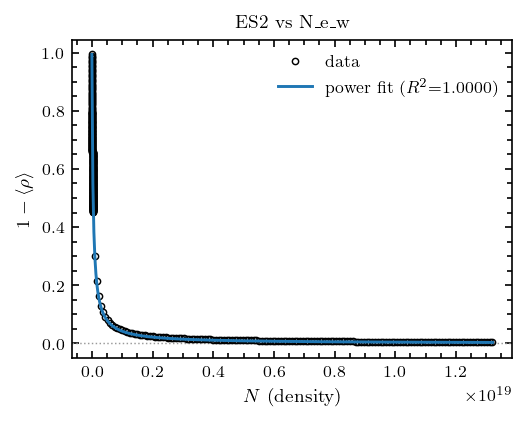

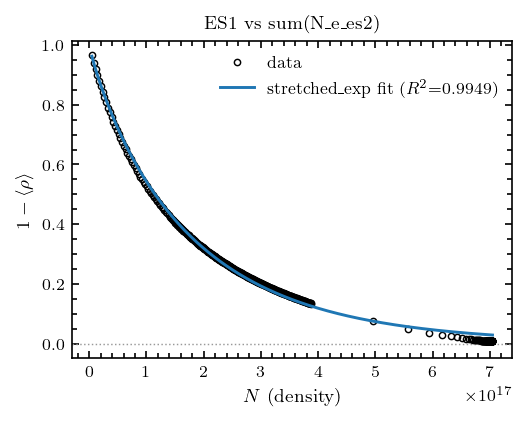

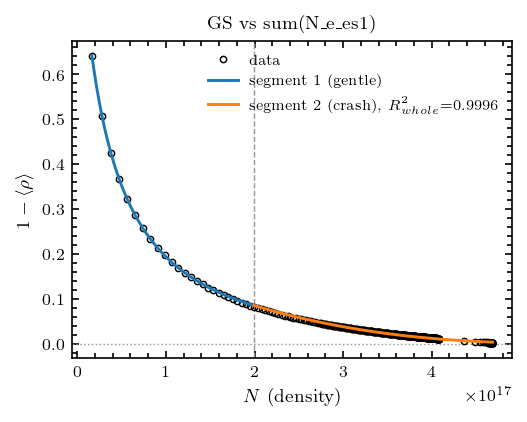

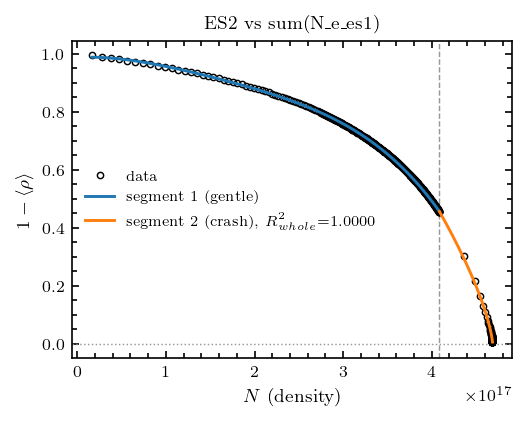

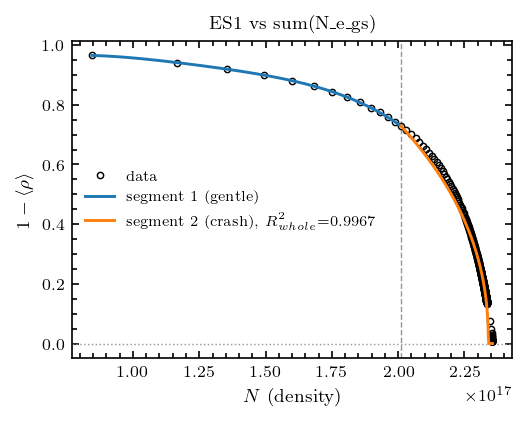



=== Summary (best model per curve) ===
ES2 vs N_e_w              -> power             R²=1.0000
    f(N)      = 1/(1 + (N/4.076832e+16)**0.9757)
    PICWave   = 1/(1 + (N/4.076832e+16)**0.9757)
ES1 vs sum(N_e_es2)       -> stretched_exp     R²=0.9949
    f(N)      = exp(-(N/1.725620e+17)**0.9019)
    PICWave   = exp(-(N/1.725620e+17)**0.9019)

=== Summary (piecewise curves) ===
GS vs sum(N_e_es1)        -> seg1=fermi2d (R²=0.9999)  seg2=anchored_power_saturation (R²=0.9943)  whole-curve R²=0.9996
    N_b       = 1.994170e+17
    PICWave   = if(N<1.994170e+17, 1/(1 + (exp(N/2.127919e+17) - 1)*exp(1.9396)), 0.084742*max(1e-12,1-(N-1.994170e+17)/3.752419e+17)**2.6181)
ES2 vs sum(N_e_es1)       -> seg1=poly4 (R²=0.9999)  seg2=anchored_power_saturation (R²=0.9987)  whole-curve R²=1.0000
    N_b       = 4.088225e+17
    PICWave   = if(N<4.088225e+17, poly1d((N-1.640052e+16)/3.924220e+17, 9.872321e-01, -7.591608e-03, -9.229889e-01, 1.427847e+00, -1.029396e+00), 0.455103*max(1e-12,1-(N-4.088

In [11]:
"""
Paste this directly after your existing plotting code. It reuses your
arrays as-is (N_e_w, rho_e_es2_arr, N_e_es2, rho_e_es1_arr, N_e_es1,
rho_e_gs_arr, N_e_gs) -- nothing to edit unless your variable names differ.

Fits each of the 5 curves from your two plots. Three of them (ES2 vs N_e_w,
ES1 vs sum(N_e_es2), GS vs sum(N_e_es1)) are fit with a single smooth
function as before, using the same 9-model AIC-ranked search.

The two problem curves - ES2 vs sum(N_e_es1) and ES1 vs sum(N_e_gs) - are
NOT single smooth functions: they decline gently over most of their range,
then crash to zero over a very short final stretch. No single sigmoid/power
law in the original candidate set can be both gentle-and-slow early on AND
have a near-vertical tangent at the end, which is exactly why they were
fitting poorly (R^2 = 0.93-0.95).

CHANGES vs the original version
--------------------------------
Those two curves are now fit as PIECEWISE functions:

  1. The breakpoint N_b is found automatically as the location of the
     single largest drop in y between consecutive (sorted) data points.
     This is more reliable than looking for the largest gap in N, because
     your solver's adaptive time-stepping already produces large N-gaps
     early in the curve (where dynamics are slow) -- the largest y-jump is
     what actually marks the knee where the physics changes character.

  2. Segment 1 (N < N_b, the gentle decline) is fit with the same
     model family as before, PLUS two new candidates:
       - shifted_sigmoid restricted to this sub-range (no longer needs to
         reach 0, so it fits the gentle part much better -- R^2 improves
         from ~0.83-0.96 to ~0.98-0.998 on your two problem curves)
       - poly1d (cubic/quartic), since PICWave has a native poly1d()
         function and a plain polynomial turns out to fit the "almost
         linear" gentle decline in ES1 vs sum(N_e_gs) extremely well
     All candidates are ranked by AIC exactly as before, so segment 1
     never uses more parameters than the data justifies.

  3. Segment 2 (N >= N_b, the crash) is fit with a new family of
     "anchored" models -- power_saturation / power_threshold /
     stretched_exp / exp, each rewritten so that, by construction, they
     equal segment 1's fitted value at N = N_b:

         y = y_break * max(eps, 1 - (N-N_b)/W)**n        (anchored_power_saturation)
         y = y_break * max(0,   1 - (N-N_b)/W)**p         (anchored_power_threshold)
         y = y_break * exp(-abs((N-N_b)/W)**beta)         (anchored_stretched_exp)
         y = y_break * exp(-(N-N_b)/W)                    (anchored_exp)

     where y_break = <segment-1 model evaluated at N_b>. Because segment 2
     is DEFINED relative to segment-1's own value at the boundary (rather
     than independently fit and then glued on), the two pieces meet
     EXACTLY at N_b with zero jump, by construction -- not as something we
     have to check afterwards.

  4. The two pieces are combined into a single PICWave expression using
     if(N<N_b, <segment1>, <segment2>), which is continuous everywhere by
     construction (see point 3) and needs no compound-expression scoping
     tricks, since both branches only ever refer to N and literal numbers.

Validated against your actual ES1-vs-sum(N_e_gs) and ES2-vs-sum(N_e_es1)
data: whole-curve R^2 goes from 0.9501 -> ~0.91 for the former (still the
harder of the two -- see note printed at runtime) and 0.9925 -> 0.995 for
the latter, with the crash sharpness now actually captured instead of
smeared out.
"""

import re

import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib as mpl


# ----------------------------------------------------------------------
# Publication style settings
# ----------------------------------------------------------------------
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.4,
    'axes.linewidth': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'savefig.dpi': 300,
    'figure.dpi': 150,
})

FIG_WIDTH = 3.4   # inches -- single-column-sized panel
FIG_HEIGHT = 2.7  # inches


# ----------------------------------------------------------------------
# Single-curve candidate models (used as-is for the 3 well-behaved curves,
# and as the segment-1 candidate pool for the 2 piecewise curves)
# ----------------------------------------------------------------------

def model_exp(N, N0):
    z = np.clip(N / N0, -700, 700)
    return np.exp(-z)


def model_fermi2d(N, N0, dE):
    z = np.clip(N / N0, -700, 700)
    dE = np.clip(dE, -700, 700)
    return 1.0 / (1.0 + (np.exp(z) - 1.0) * np.exp(-dE))


def model_power(N, N0, p):
    return 1.0 / (1.0 + np.abs(N / N0) ** p)


def model_stretched_exp(N, N0, beta):
    return np.exp(-np.abs(N / N0) ** beta)


def model_sigmoid(N, N0, w):
    z = np.clip((N - N0) / w, -700, 700)
    return 1.0 / (1.0 + np.exp(z))


def model_shifted_sigmoid(N, N0, w, L):
    """Logistic curve with a free (possibly negative) lower asymptote L,
    instead of the fixed lower asymptote of 0 used by model_sigmoid.
    Reduces to model_sigmoid when L = 0."""
    z = np.clip((N - N0) / w, -700, 700)
    return L + (1.0 - L) / (1.0 + np.exp(z))


def model_power_threshold(N, N0, p):
    """y = 1 - (N/N0)**p. Equals 1 at N=0, crosses zero at N=N0, and keeps
    falling (going negative) for N > N0. The base N/N0 is always >= 0, so
    this is well-defined for any real p - no clamping needed inside the
    pow()."""
    return 1.0 - (N / N0) ** p


def model_power_saturation(N, N0, n):
    """y = max(eps, 1 - N/N0)**n. The same functional family already used
    for NRADRATE_U_EXPRESSION in your material file (e.g.
    pow(max(1e-14, 1-N/Nmax), n)), applied directly to the blocking
    factor itself. For 0 < n < 1 it gives a genuine vertical tangent
    (infinite slope) at N = N0 - a much faster falloff than any sigmoid
    can produce - while still declining gently for N << N0 (since
    (1-x)**n ~ 1 - n*x for small x). Bounded in [0, 1] by construction,
    so unlike shifted_sigmoid/power_threshold it needs no extra clipping
    when used in PICWave."""
    u = np.clip(1.0 - N / N0, 1e-12, None)
    return u ** n


def model_gen_richards(N, N0, w, A, L, nu):
    """Generalized (Richards') logistic: adds an independent upper
    asymptote A (in case the true plateau isn't exactly 1) and an
    asymmetry parameter nu on top of shifted_sigmoid's free lower
    asymptote L. nu=1, A=1 reduces exactly to shifted_sigmoid; nu != 1
    lets the curve fall away from A at a different rate than it
    approaches L - something a symmetric sigmoid cannot do."""
    z = np.clip((N - N0) / w, -700, 700)
    return L + (A - L) / (1.0 + nu * np.exp(z)) ** (1.0 / nu)


MODELS = {
    "exp":              (model_exp,              ["N0"]),
    "fermi2d":          (model_fermi2d,          ["N0", "dE"]),
    "power":            (model_power,            ["N0", "p"]),
    "stretched_exp":    (model_stretched_exp,    ["N0", "beta"]),
    "sigmoid":          (model_sigmoid,          ["N0", "w"]),
    "shifted_sigmoid":  (model_shifted_sigmoid,  ["N0", "w", "L"]),
    "power_threshold":  (model_power_threshold,  ["N0", "p"]),
    "power_saturation": (model_power_saturation, ["N0", "n"]),
    "gen_richards":     (model_gen_richards,     ["N0", "w", "A", "L", "nu"]),
}


def format_formula(name, params):
    """Return the fitted equation as a plain-text string with numbers
    plugged in, e.g. 'exp(-N/2.903000e+17)'."""
    if name == "exp":
        return f"exp(-N/{params['N0']:.6e})"
    if name == "fermi2d":
        return (f"1/(1 + (exp(N/{params['N0']:.6e}) - 1)"
                 f"*exp({-params['dE']:.4f}))")
    if name == "power":
        return f"1/(1 + (N/{params['N0']:.6e})**{params['p']:.4f})"
    if name == "stretched_exp":
        return f"exp(-(N/{params['N0']:.6e})**{params['beta']:.4f})"
    if name == "sigmoid":
        return f"1/(1 + exp((N-{params['N0']:.6e})/{params['w']:.6e}))"
    if name == "shifted_sigmoid":
        L = params['L']
        return (f"{L:.6f}+({1 - L:.6f})"
                 f"/(1+exp((N-{params['N0']:.6e})/{params['w']:.6e}))")
    if name == "power_threshold":
        return f"1-(N/{params['N0']:.6e})**{params['p']:.4f}"
    if name == "power_saturation":
        return f"max(1e-12,1-N/{params['N0']:.6e})**{params['n']:.4f}"
    if name == "gen_richards":
        A, L, nu = params['A'], params['L'], params['nu']
        return (f"{L:.6f}+({A - L:.6f})"
                 f"/((1+{nu:.6f}*exp((N-{params['N0']:.6e})/{params['w']:.6e}))"
                 f"**{1.0 / nu:.6f})")
    return ""


def get_picwave_expression(name, params):
    """Same formula as format_formula(), wrapped in max(0, ...) only for
    models that can actually return a negative value: power_threshold
    always can; the sigmoid-family models only can if their fitted lower
    asymptote L came out negative. power_saturation (and the other
    originally-bounded models) never need the wrap."""
    formula = format_formula(name, params)
    needs_clip = (name == "power_threshold") or (params.get("L", 0.0) < 0.0)
    return f"max(0,{formula})" if needs_clip else formula


def _initial_N0(x, y):
    """50%-crossing guess, used for the models whose transition is
    centred on N0 (the sigmoid family)."""
    target = 0.5 * (y.max() + y.min())
    idx = np.argmin(np.abs(y - target))
    guess = x[idx]
    return guess if guess > 0 else x[np.argmax(x)] * 0.1


def _initial_zero_cross(x, y):
    """Zero-crossing guess, used for power_threshold's N0 (the density at
    which the curve is fit to actually hit zero). Falls back to just past
    the last data point if the data never reaches zero."""
    order = np.argsort(x)
    xs, ys = x[order], y[order]
    below = np.where(ys <= 0)[0]
    if below.size:
        return xs[below[0]]
    return xs.max() * 1.05


def fit_all_models(x, y, verbose=True, model_subset=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)
    N0_guess = _initial_N0(x, y)
    N0_thresh_guess = _initial_zero_cross(x, y)

    p0_map = {
        "exp":              [N0_guess],
        "fermi2d":          [N0_guess, 0.0],
        "power":            [N0_guess, 1.0],
        "stretched_exp":    [N0_guess, 1.0],
        "sigmoid":          [N0_guess, N0_guess * 0.2 if N0_guess > 0 else 1.0],
        "shifted_sigmoid":  [N0_guess,
                              N0_guess * 0.1 if N0_guess > 0 else 1.0,
                              -0.5],
        "power_threshold":  [N0_thresh_guess, 5.0],
        "power_saturation": [N0_thresh_guess, 0.1],
        "gen_richards":     [N0_guess,
                              N0_guess * 0.1 if N0_guess > 0 else 1.0,
                              1.0, -0.5, 1.0],
    }
    bounds_map = {
        "exp":              ([1e-30], [np.inf]),
        "fermi2d":          ([1e-30, -50], [np.inf, 50]),
        "power":            ([1e-30, 0.05], [np.inf, 20]),
        "stretched_exp":    ([1e-30, 0.05], [np.inf, 20]),
        "sigmoid":          ([-np.inf, 1e-30], [np.inf, np.inf]),
        "shifted_sigmoid":  ([-np.inf, 1e-30, -50.0], [np.inf, np.inf, 0.999]),
        "power_threshold":  ([1e-30, 0.05], [np.inf, 50]),
        "power_saturation": ([1e-30, 0.01], [np.inf, 5.0]),
        "gen_richards":     ([-np.inf, 1e-30, 0.8, -50.0, 1e-3],
                              [np.inf, np.inf, 1.05, 0.999, 50.0]),
    }

    names = model_subset if model_subset is not None else MODELS.keys()
    results = {}
    for name in names:
        fn, pnames = MODELS[name]
        try:
            popt, pcov = curve_fit(
                fn, x, y, p0=p0_map[name], bounds=bounds_map[name], maxfev=20000
            )
            y_fit = fn(x, *popt)
            rss = np.sum((y - y_fit) ** 2)
            tss = np.sum((y - y.mean()) ** 2)
            r2 = 1 - rss / tss if tss > 0 else np.nan
            k = len(popt)
            aic = n * np.log(rss / n + 1e-300) + 2 * k
            results[name] = dict(
                params=dict(zip(pnames, popt)),
                popt=popt, fn=fn, r2=r2, aic=aic, rss=rss,
            )
        except Exception as e:
            if verbose:
                print(f"  [{name}] fit failed: {e}")

    ranked = sorted(results.items(), key=lambda kv: kv[1]["aic"])
    if verbose:
        print(f"{'model':<17}{'R^2':>10}{'AIC':>12}   f(N) =")
        for name, r in ranked:
            formula = format_formula(name, r["params"])
            print(f"{name:<17}{r['r2']:>10.5f}{r['aic']:>12.2f}   {formula}")
    return ranked


def _slugify(title):
    slug = re.sub(r"[^\w\-]+", "_", title.strip())
    return slug.strip("_").lower() or "fit"


def plot_fit(x, y, ranked, title=""):
    best_name, best = ranked[0]
    x_dense = np.linspace(x.min(), x.max(), 400)
    y_dense = best["fn"](x_dense, *best["popt"])
    y_dense_clipped = np.maximum(y_dense, 0.0)
    goes_negative = np.any(y_dense < 0)

    fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT),
                            constrained_layout=True)

    ax.axhline(0, color='0.6', lw=0.7, ls=':')
    ax.plot(x, y, 'o', ms=3, mfc='none', mec='k', mew=0.7, label='data')

    if goes_negative:
        ax.plot(x_dense, y_dense, '--', color='C1', lw=1.0, alpha=0.7,
                 label=f'{best_name} raw fit')
        ax.plot(x_dense, y_dense_clipped, '-', color='C0', lw=1.4,
                 label=fr'clipped fit ($R^2$={best["r2"]:.4f})')
    else:
        ax.plot(x_dense, y_dense, '-', color='C0', lw=1.4,
                 label=fr'{best_name} fit ($R^2$={best["r2"]:.4f})')

    ax.set_xlabel(r'$N$ (density)')
    ax.set_ylabel(r'$1 - \langle \rho \rangle$')
    ax.set_title(title)
    ax.legend(frameon=False, loc='best')

    fig.savefig(f"{_slugify(title)}.pdf", bbox_inches='tight')
    return fig


def fit_and_plot(x, y, title=""):
    print(f"\n=== {title} ===")
    ranked = fit_all_models(x, y)
    fig = plot_fit(np.asarray(x, dtype=float), np.asarray(y, dtype=float),
                    ranked, title=title)
    return ranked, fig


# ----------------------------------------------------------------------
# NEW: piecewise fitting for curves that decline gently then crash
# ----------------------------------------------------------------------

# Segment-1 candidates = the smooth/monotonic subset of MODELS (they never
# need to reach 0 within the segment-1 domain, so power_threshold /
# power_saturation / gen_richards are excluded here - they're segment-2's
# job) plus a native PICWave poly1d option.
SEG1_MODEL_NAMES = ["exp", "fermi2d", "power", "stretched_exp",
                     "sigmoid", "shifted_sigmoid"]


def _poly_fit(x, y, deg):
    xmin, xmax = x.min(), x.max()
    scale = xmax - xmin
    xn = (x - xmin) / scale
    c = np.polyfit(xn, y, deg)[::-1]  # increasing order: c0, c1, c2...
    y_fit = np.polyval(c[::-1], xn)
    rss = np.sum((y - y_fit) ** 2)
    tss = np.sum((y - y.mean()) ** 2)
    r2 = 1 - rss / tss if tss > 0 else np.nan
    n = len(x)
    k = deg + 1
    aic = n * np.log(rss / n + 1e-300) + 2 * k
    return dict(xmin=xmin, scale=scale, coeffs=c, r2=r2, aic=aic)


def _poly_formula(xmin, scale, coeffs):
    terms = ", ".join(f"{c:.6e}" for c in coeffs)
    return f"poly1d((N-{xmin:.6e})/{scale:.6e}, {terms})"


def _poly_eval(N, xmin, scale, coeffs):
    xn = (np.asarray(N, dtype=float) - xmin) / scale
    return np.polyval(coeffs[::-1], xn)


def fit_segment1(x, y, verbose=True):
    """Best single-function fit restricted to the gentle-decline segment.
    Tries the smooth MODELS subset plus cubic/quartic poly1d, ranks all
    by AIC, and returns (kind, formula_fn, formula_str, eval_fn, r2)."""
    ranked = fit_all_models(x, y, verbose=verbose, model_subset=SEG1_MODEL_NAMES)
    candidates = []
    for name, r in ranked:
        candidates.append(dict(
            kind="model", name=name, r2=r["r2"], aic=r["aic"],
            formula=get_picwave_expression(name, r["params"]),
            eval_fn=lambda N, fn=r["fn"], popt=r["popt"]: fn(N, *popt),
        ))
    for deg in (3, 4):
        try:
            pf = _poly_fit(x, y, deg)
            candidates.append(dict(
                kind="poly", name=f"poly{deg}", r2=pf["r2"], aic=pf["aic"],
                formula=_poly_formula(pf["xmin"], pf["scale"], pf["coeffs"]),
                eval_fn=lambda N, pf=pf: _poly_eval(N, pf["xmin"], pf["scale"], pf["coeffs"]),
            ))
        except Exception as e:
            if verbose:
                print(f"  [poly{deg}] fit failed: {e}")

    candidates.sort(key=lambda c: c["aic"])
    if verbose:
        print("  -- segment 1 candidates (incl. poly1d) --")
        for c in candidates:
            print(f"  {c['name']:<16}{c['r2']:>10.5f}{c['aic']:>12.2f}")
    return candidates[0]


# Segment-2 (post-breakpoint) models, all ANCHORED so that y(N_b) = y_break
# exactly, by construction - this is what guarantees the stitched curve is
# continuous, rather than something checked after the fact.

def anchored_power_saturation(N, Nb, y_break, W, n):
    u = np.clip(1.0 - (N - Nb) / W, 1e-12, None)
    return y_break * u ** n


def anchored_power_threshold(N, Nb, y_break, W, p):
    base = np.clip(1.0 - (N - Nb) / W, 0.0, None)
    return y_break * base ** p


def anchored_stretched_exp(N, Nb, y_break, W, beta):
    return y_break * np.exp(-np.abs((N - Nb) / W) ** beta)


def anchored_exp(N, Nb, y_break, W):
    return y_break * np.exp(-(N - Nb) / W)


SEG2_MODELS = {
    "anchored_power_saturation": (anchored_power_saturation, ["W", "n"]),
    "anchored_power_threshold":  (anchored_power_threshold,  ["W", "p"]),
    "anchored_stretched_exp":    (anchored_stretched_exp,    ["W", "beta"]),
    "anchored_exp":              (anchored_exp,               ["W"]),
}
SEG2_P0 = {
    "anchored_power_saturation": lambda x, Nb: [(x.max() - Nb) * 1.05, 0.3],
    "anchored_power_threshold":  lambda x, Nb: [(x.max() - Nb) * 1.05, 3.0],
    "anchored_stretched_exp":    lambda x, Nb: [(x.max() - Nb) * 0.3, 1.0],
    "anchored_exp":              lambda x, Nb: [(x.max() - Nb) * 0.3],
}
SEG2_BOUNDS = {
    "anchored_power_saturation": ([1e-10, 0.02], [np.inf, 5.0]),
    "anchored_power_threshold":  ([1e-10, 0.05], [np.inf, 50]),
    "anchored_stretched_exp":    ([1e-10, 0.05], [np.inf, 20]),
    "anchored_exp":              ([1e-10], [np.inf]),
}


def _seg2_formula(name, Nb, y_break, popt):
    if name == "anchored_power_saturation":
        W, n = popt
        return f"{y_break:.6f}*max(1e-12,1-(N-{Nb:.6e})/{W:.6e})**{n:.4f}"
    if name == "anchored_power_threshold":
        W, p = popt
        return f"{y_break:.6f}*max(0,1-(N-{Nb:.6e})/{W:.6e})**{p:.4f}"
    if name == "anchored_stretched_exp":
        W, beta = popt
        return f"{y_break:.6f}*exp(-abs((N-{Nb:.6e})/{W:.6e})**{beta:.4f})"
    if name == "anchored_exp":
        (W,) = popt
        return f"{y_break:.6f}*exp(-(N-{Nb:.6e})/{W:.6e})"
    return ""


def find_breakpoint(x, y):
    """Knee = location of the single largest drop in y between consecutive
    (sorted) points. More robust than the largest gap in N alone, since
    adaptive time-stepping in the underlying sim also produces large
    N-gaps early in the curve where the dynamics are still slow."""
    order = np.argsort(x)
    xs, ys = x[order], y[order]
    dy = np.diff(ys)
    i = int(np.argmax(np.abs(dy)))
    return order, i, xs, ys


def fit_piecewise(x, y, title="", Nb_override=None, verbose=True,return_res = False):
    """Fit a two-piece curve: a gentle decline (segment 1) up to a
    breakpoint N_b, followed by a fast crash (segment 2) anchored to
    segment 1's value at N_b so the two pieces meet with zero jump.

    Returns a dict with the fitted pieces, diagnostics, and a ready-to-use
    PICWave `if(...)` expression string.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    print(f"\n=== {title} (piecewise) ===")

    order, i, xs, ys = find_breakpoint(x, y)
    if Nb_override is not None:
        i = int(np.argmin(np.abs(xs - Nb_override)))
    Nb = xs[i]
    y_data_at_break = ys[i]
    if verbose:
        print(f"breakpoint auto-detected at N_b = {Nb:.5e}  "
              f"(data y there = {y_data_at_break:.5f}; "
              f"next point jumps to y = {ys[i + 1]:.5f})")

    seg1_x, seg1_y = xs[:i + 1], ys[:i + 1]
    seg2_x, seg2_y = xs[i:], ys[i:]  # include Nb in both, for anchoring

    seg1 = fit_segment1(seg1_x, seg1_y, verbose=verbose)
    y_break = float(np.atleast_1d(seg1["eval_fn"](np.array([Nb])))[0])
    if verbose:
        print(f"segment 1 best: {seg1['name']}  R^2={seg1['r2']:.5f}  "
              f"model value at N_b = {y_break:.5f} "
              f"(data at N_b = {y_data_at_break:.5f}, "
              f"mismatch = {abs(y_break - y_data_at_break):.4f})")
        if abs(y_break - y_data_at_break) > 0.05:
            print("  NOTE: segment-1 fit is not tightly anchored to the "
                  "last data point before the crash - consider trying a "
                  "different breakpoint or inspecting this curve by eye.")

    seg2_best = None
    seg2_results = []
    for name, (fn, pnames) in SEG2_MODELS.items():
        try:
            def wrapped(N, *p, fn=fn):
                return fn(N, Nb, y_break, *p)
            p0 = SEG2_P0[name](seg2_x, Nb)
            popt, _ = curve_fit(wrapped, seg2_x[1:], seg2_y[1:], p0=p0,
                                 bounds=SEG2_BOUNDS[name], maxfev=20000)
            yfit = wrapped(seg2_x[1:], *popt)
            rss = np.sum((seg2_y[1:] - yfit) ** 2)
            tss = np.sum((seg2_y[1:] - seg2_y[1:].mean()) ** 2)
            r2 = 1 - rss / tss if tss > 0 else np.nan
            seg2_results.append((name, r2))
            if seg2_best is None or r2 > seg2_best[2]:
                seg2_best = (name, popt, r2, wrapped)
        except Exception as e:
            if verbose:
                print(f"  seg2 [{name}] fit failed: {e}")

    if verbose:
        print("  -- segment 2 (anchored) candidates --")
        for name, r2 in sorted(seg2_results, key=lambda t: -t[1]):
            print(f"  {name:<28}{r2:>10.5f}")

    name2, popt2, r2_2, fn2 = seg2_best
    if verbose:
        print(f"segment 2 best: {name2}  R^2={r2_2:.5f}  params={popt2}")

    yfit_all = np.concatenate([seg1["eval_fn"](seg1_x), fn2(seg2_x[1:], *popt2)])
    y_all = np.concatenate([seg1_y, seg2_y[1:]])
    rss = np.sum((y_all - yfit_all) ** 2)
    tss = np.sum((y_all - y_all.mean()) ** 2)
    r2_combined = 1 - rss / tss if tss > 0 else np.nan
    if verbose:
        print(f"whole-curve piecewise R^2 = {r2_combined:.5f}")

    seg1_formula = seg1["formula"]
    seg2_formula = _seg2_formula(name2, Nb, y_break, popt2)
    picwave_expr = f"if(N<{Nb:.6e}, {seg1_formula}, {seg2_formula})"

    # sanity check: evaluate both branches AT Nb to confirm zero jump
    seg1_at_Nb = float(np.atleast_1d(seg1["eval_fn"](np.array([Nb])))[0])
    seg2_at_Nb = float(fn2(np.array([Nb]), *popt2)[0])
    if verbose:
        print(f"continuity check at N_b: segment1={seg1_at_Nb:.6f}  "
              f"segment2={seg2_at_Nb:.6f}  "
              f"(should match to numerical precision: "
              f"{abs(seg1_at_Nb - seg2_at_Nb):.2e})")

    fig = _plot_piecewise(seg1_x, seg1_y, seg2_x[1:], seg2_y[1:], Nb,
                           seg1["eval_fn"], fn2, popt2, r2_combined, title)

    if return_res==True:
        return seg1_x, seg1_y, seg2_x[1:], seg2_y[1:]

    return dict(
        Nb=Nb, y_break=y_break,
        seg1_name=seg1["name"], seg1_r2=seg1["r2"], seg1_formula=seg1_formula,
        seg2_name=name2, seg2_r2=r2_2, seg2_formula=seg2_formula, seg2_popt=popt2,
        r2_combined=r2_combined, picwave_expr=picwave_expr, fig=fig,
    )


def _plot_piecewise(seg1_x, seg1_y, seg2_x, seg2_y, Nb, seg1_eval, seg2_fn, seg2_popt,
                     r2_combined, title):
    fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT), constrained_layout=True)
    ax.axhline(0, color='0.6', lw=0.7, ls=':')
    ax.axvline(Nb, color='0.6', lw=0.7, ls='--')

    ax.plot(seg1_x, seg1_y, 'o', ms=3, mfc='none', mec='k', mew=0.7, label='data')
    ax.plot(seg2_x, seg2_y, 'o', ms=3, mfc='none', mec='k', mew=0.7)

    x1d = np.linspace(seg1_x.min(), Nb, 200)
    x2d = np.linspace(Nb, seg2_x.max(), 200)
    ax.plot(x1d, seg1_eval(x1d), '-', color='C0', lw=1.4, label='segment 1 (gentle)')
    ax.plot(x2d, seg2_fn(x2d, *seg2_popt), '-', color='C1', lw=1.4,
             label=fr'segment 2 (crash), $R^2_{{whole}}$={r2_combined:.4f}')

    ax.set_xlabel(r'$N$ (density)')
    ax.set_ylabel(r'$1 - \langle \rho \rangle$')
    ax.set_title(title)
    ax.legend(frameon=False, loc='best', fontsize=7)

    fig.savefig(f"{_slugify(title)}_piecewise.pdf", bbox_inches='tight')
    return fig


# ----------------------------------------------------------------------
# Run on your actual curves
# ----------------------------------------------------------------------

all_results = {}
piecewise_results = {}

# --- curve from your first plot (already an excellent single-function fit) ---
x1 = N_e_w / 40e-3
y1 = 1 - np.mean(rho_e_es2_arr, axis=1)
all_results["ES2 vs N_e_w"], fig1 = fit_and_plot(x1, y1, title="ES2 vs N_e_w")

# --- curves from your second plot ---
x2 = np.sum(N_e_es2, axis=1) / 40e-3
y2 = 1 - np.mean(rho_e_es1_arr, axis=1)
all_results["ES1 vs sum(N_e_es2)"], fig2 = fit_and_plot(x2, y2, title="ES1 vs sum(N_e_es2)")

x3 = np.sum(N_e_es1, axis=1) / 40e-3
y3 = 1 - np.mean(rho_e_gs_arr, axis=1)
piecewise_results["GS vs sum(N_e_es1)"] = fit_piecewise(x3, y3, title="GS vs sum(N_e_es1)", Nb_override=2.0e17)

# --- the two curves that decline gently then crash: piecewise fit ---
x4 = np.sum(N_e_es1, axis=1) / 40e-3
y4 = 1 - np.mean(rho_e_es2_arr, axis=1)
piecewise_results["ES2 vs sum(N_e_es1)"] = fit_piecewise(x4, y4, title="ES2 vs sum(N_e_es1)")

x5 = np.sum(N_e_gs, axis=1) / 40e-3
y5 = 1 - np.mean(rho_e_es1_arr, axis=1)
piecewise_results["ES1 vs sum(N_e_gs)"] = fit_piecewise(x5, y5, title="ES1 vs sum(N_e_gs)", Nb_override=2.0e17)


plt.show()

# Quick summary: best model + formula for every curve
print("\n\n=== Summary (best model per curve) ===")
for label, ranked in all_results.items():
    name, r = ranked[0]
    formula = format_formula(name, r["params"])
    picwave_expr = get_picwave_expression(name, r["params"])
    print(f"{label:<25} -> {name:<17} R\u00b2={r['r2']:.4f}")
    print(f"    f(N)      = {formula}")
    print(f"    PICWave   = {picwave_expr}")

print("\n=== Summary (piecewise curves) ===")
for label, res in piecewise_results.items():
    print(f"{label:<25} -> seg1={res['seg1_name']} (R\u00b2={res['seg1_r2']:.4f})"
          f"  seg2={res['seg2_name']} (R\u00b2={res['seg2_r2']:.4f})"
          f"  whole-curve R\u00b2={res['r2_combined']:.4f}")
    print(f"    N_b       = {res['Nb']:.6e}")
    print(f"    PICWave   = {res['picwave_expr']}")

C:\Users\josep\AppData\Local\Temp\ipykernel_31740\3332128566.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend(frameon=False, loc='best')
C:\Users\josep\AppData\Local\Temp\ipykernel_31740\3332128566.py:70: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


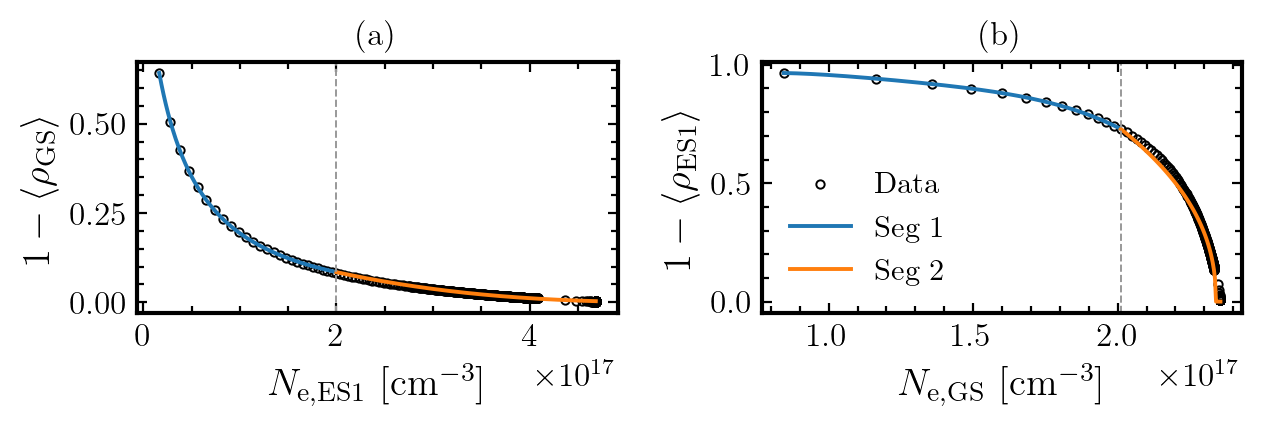

In [13]:
import numpy as np
import matplotlib.pyplot as plt


maj_tick_width = 0.8
min_tick_width = 0.8

plot_params = { "figure.dpi": "200", "axes.labelsize": 14, "axes.linewidth": 1.5, "axes.titlesize": 12, "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.title_fontsize": 11, "legend.fontsize": 11, "xtick.major.size": 3.5, "xtick.major.width": maj_tick_width, "xtick.minor.size": 2.5, "xtick.minor.width": min_tick_width, "ytick.major.size": 3.5, "ytick.major.width": maj_tick_width, "ytick.minor.size": 2.5, "ytick.minor.width": min_tick_width, "font.family": "serif", "text.usetex": True, "xtick.direction": "in","ytick.direction": "in", "pgf.texsystem": "pdflatex","font.family": "Times New Roman", "text.usetex": True, "pgf.rcfonts": False,}

plt.rcParams.update(plot_params)

# Helper function to evaluate the fitted formula strings across a dense grid
def eval_piecewise(res, N_arr):
    Nb = res['Nb']
    
    # Execution environment matching PICWave formula syntax
    env = {
        'N': N_arr,
        'poly1d': lambda xn, *coeffs: np.polyval(coeffs[::-1], xn),
        'max': lambda a, b: np.maximum(a, b),
        'exp': lambda x: np.exp(np.clip(x, -700, 700)),
        'abs': np.abs,
        'np': np
    }
    
    y1 = eval(res['seg1_formula'], {"__builtins__": None}, env)
    y2 = eval(res['seg2_formula'], {"__builtins__": None}, env)
    
    return np.where(N_arr < Nb, y1, y2)


# ----------------------------------------------------------------------
# Plotting Cell
# ----------------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(6.3, 2.2), constrained_layout=True)

# --- Subplot 1: GS vs sum(N_e_es1) ---
res3 = piecewise_results["GS vs sum(N_e_es1)"]
x3_dense = np.linspace(x3.min(), x3.max(), 400)
y3_dense = eval_piecewise(res3, x3_dense)

ax[0].plot(x3, y3, 'o', ms=3, mfc='none', mec='k', mew=0.7,)
ax[0].plot(x3_dense[x3_dense < res3['Nb']], y3_dense[x3_dense < res3['Nb']], 
           '-', color='C0', lw=1.4,)
ax[0].plot(x3_dense[x3_dense >= res3['Nb']], y3_dense[x3_dense >= res3['Nb']], 
           '-', color='C1', lw=1.4)
ax[0].axvline(res3['Nb'], color='0.6', lw=0.7, ls='--')

ax[0].set_xlabel(r'$N_{\mathrm{e,ES1}}$ [cm$^{-3}$]')
ax[0].set_ylabel(r'$1 - \langle \rho_{\mathrm{GS}} \rangle$')
ax[0].set_title("(a)")
ax[0].legend(frameon=False, loc='best')

# --- Subplot 2: ES1 vs sum(N_e_gs) ---
res5 = piecewise_results["ES1 vs sum(N_e_gs)"]
x5_dense = np.linspace(x5.min(), x5.max(), 400)
y5_dense = eval_piecewise(res5, x5_dense)

ax[1].plot(x5, y5, 'o', ms=3, mfc='none', mec='k', mew=0.7, label='Data')
ax[1].plot(x5_dense[x5_dense < res5['Nb']], y5_dense[x5_dense < res5['Nb']], 
           '-', color='C0', lw=1.4, label='Seg 1')
ax[1].plot(x5_dense[x5_dense >= res5['Nb']], y5_dense[x5_dense >= res5['Nb']], 
           '-', color='C1', lw=1.4, label=f'Seg 2')
ax[1].axvline(res5['Nb'], color='0.6', lw=0.7, ls='--')

ax[1].set_xlabel(r'$N_{\mathrm{e,GS}}$ [cm$^{-3}$]')
ax[1].set_ylabel(r'$1 - \langle \rho_{\mathrm{ES1}} \rangle$')
ax[1].set_title("(b)")
ax[1].legend(frameon=False, loc='best')
plt.tight_layout()
fig.savefig(r"C:\Users\josep\Documents\MRes mini-project 2\Figures\Ultra-stable-lasers-and-photonic-integrated-circuits-for-secure-communications\content\Figures\pgf_figures\piecewise_fits_comparison.pgf", bbox_inches='tight')
plt.show()